In [1]:
import os 
import pandas as pd

OASIS_PATH = os.path.join("..", "data", "raw", "oasis_longitudinal.csv")

def load_oasis_data(oasis_path = OASIS_PATH):
    return pd.read_csv(oasis_path)

oasis = load_oasis_data()
oasis.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [2]:
oasis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    object 
 1   MRI ID      373 non-null    object 
 2   Group       373 non-null    object 
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    object 
 6   Hand        373 non-null    object 
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    int64  
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(5), int64(5), object(5)
memory usage: 43.8+ KB


"Group" é a nossa variável target, mas está na forma categórica, precisa ser numérica para a divisão de grupos de teste e treinamento.
"M/F" também é categórica e pode ser transformada em numérica sem problemas antes da divisão.
"Subject ID" e "MRI ID" são identificadores, eles não afetam o modelo, então dá pra excluir.
"Hand" só possui um valor, "R". Como todas as inserções tem esse valor, é possível excluir essa coluna.

In [3]:
#fazendo cópia da tabela para não mexer na original
oasis_prepared = oasis.copy()

#fazendo mapping para transformar variável target categórica em numérica
mapeamento_target = {
    'Nondemented': 0,
    'Demented': 1,
    'Converted': 1
}

oasis_prepared['Group'] = oasis_prepared['Group'].map(mapeamento_target)
oasis_prepared['Group'].value_counts()



Group
0    190
1    183
Name: count, dtype: int64

In [4]:
#deletando colunas com informações irrelevantes 
oasis_prepared.drop(['Subject ID', 'MRI ID', 'Hand'], axis=1, inplace=True)

In [5]:
#criando coluna numérica para "M/F"
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(drop= 'if_binary', sparse_output=False)
encoded_data = enc.fit_transform(oasis_prepared[['M/F']])

#adicionando nova coluna e excluindo a anterior
oasis_prepared['Gender'] = encoded_data
oasis_prepared.drop('M/F', axis=1, inplace=True)
oasis_prepared.head()

,Group,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,Gender
0,0,1,0,87,14,2.0,27.0,0.0,1987,0.696,0.883,1.0
1,0,2,457,88,14,2.0,30.0,0.0,2004,0.681,0.876,1.0
2,1,1,0,75,12,NaN,23.0,0.5,1678,0.736,1.046,1.0
3,1,2,560,76,12,NaN,28.0,0.5,1738,0.713,1.010,1.0
4,1,3,1895,80,12,NaN,22.0,0.5,1698,0.701,1.034,1.0


In [6]:
oasis_prepared.describe()

,Group,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,Gender
count,373.000000,373.000000,373.000000,373.000000,373.000000,354.000000,371.000000,373.000000,373.000000,373.000000,373.000000,373.000000
mean,0.490617,1.882038,595.104558,77.013405,14.597855,2.460452,27.342318,0.290885,1488.128686,0.729568,1.195461,0.428954
std,0.500583,0.922843,635.485118,7.640957,2.876339,1.134005,3.683244,0.374557,176.139286,0.037135,0.138092,0.495592
min,0.000000,1.000000,0.000000,60.000000,6.000000,1.000000,4.000000,0.000000,1106.000000,0.644000,0.876000,0.000000
25%,0.000000,1.000000,0.000000,71.000000,12.000000,2.000000,27.000000,0.000000,1357.000000,0.700000,1.099000,0.000000
50%,0.000000,2.000000,552.000000,77.000000,15.000000,2.000000,29.000000,0.000000,1470.000000,0.729000,1.194000,0.000000
75%,1.000000,2.000000,873.000000,82.000000,16.000000,3.000000,30.000000,0.500000,1597.000000,0.756000,1.293000,1.000000
max,1.000000,5.000000,2639.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.000000,0.837000,1.587000,1.000000


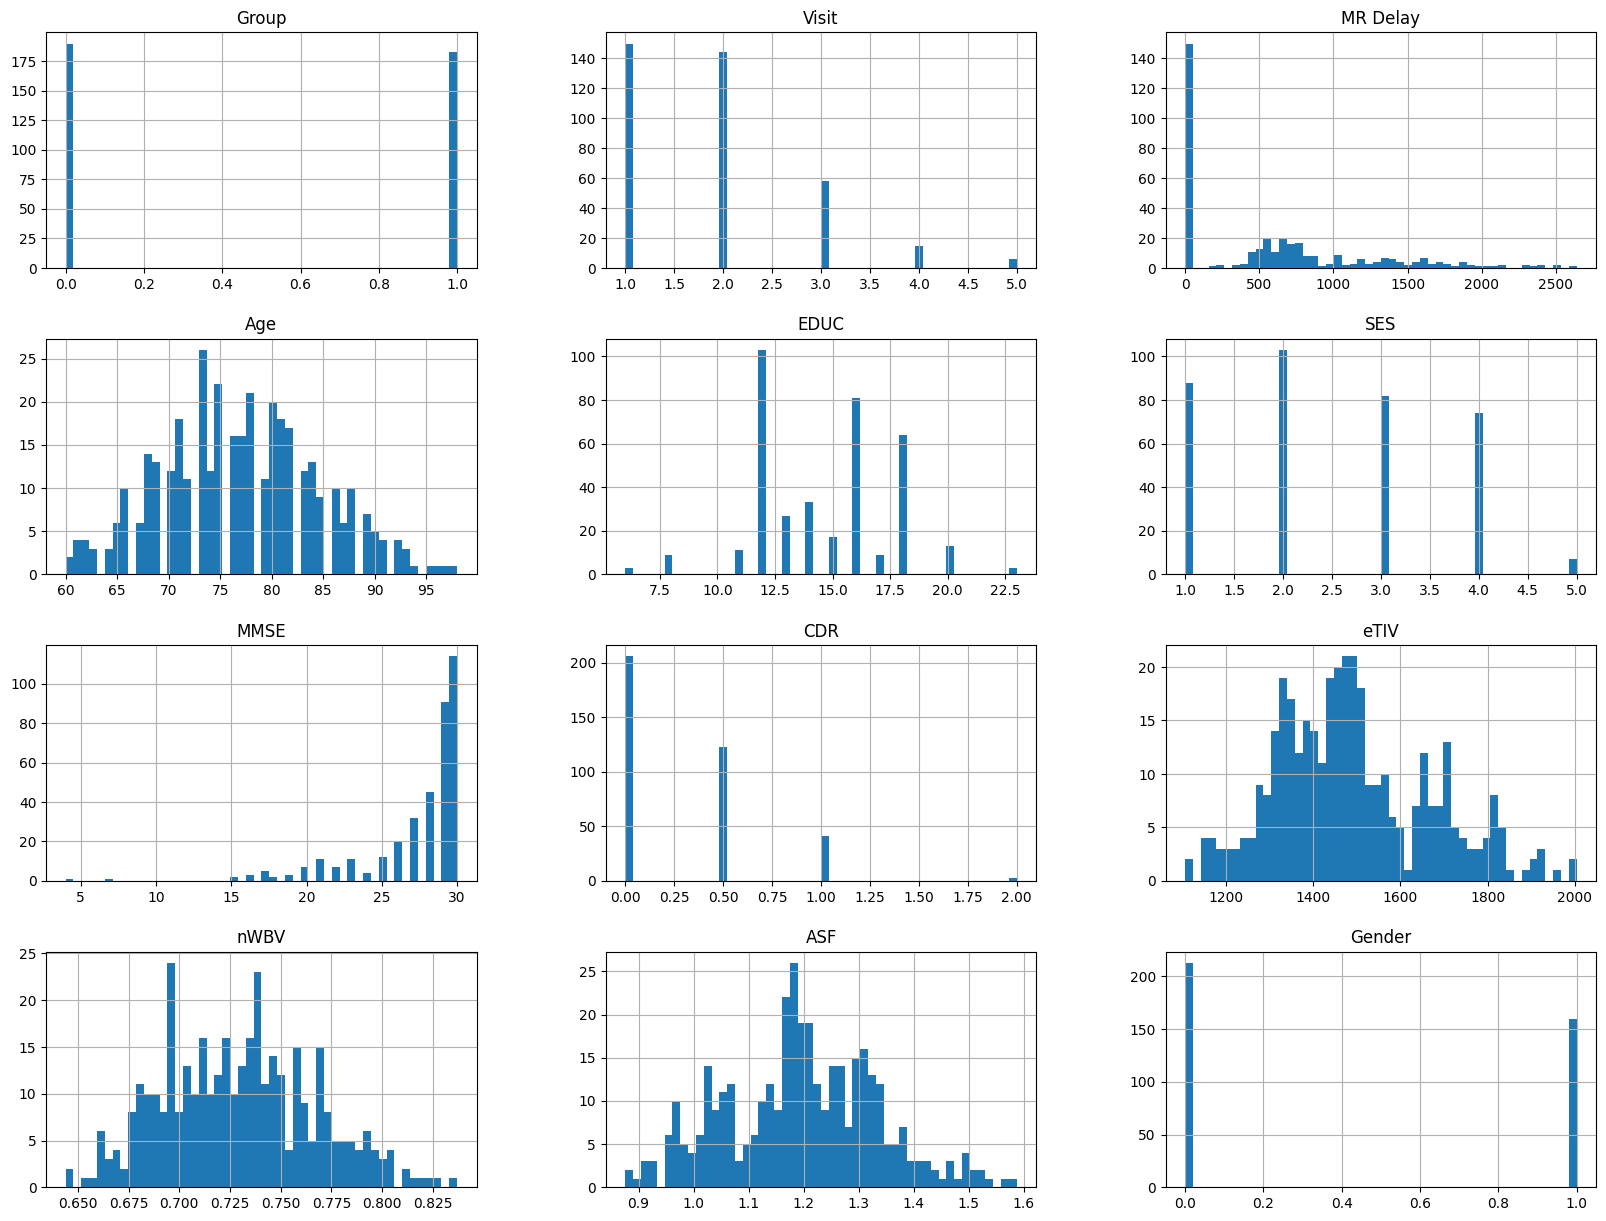

In [7]:
import matplotlib.pyplot as plt
oasis_prepared.hist(bins=50, figsize=(20,15))
plt.show()

In [8]:
OASIS_PREPARED_PATH = os.path.join("..", "data", "interim", "oasis_prepared.csv")
oasis_prepared.to_csv(OASIS_PREPARED_PATH, index=False)